In [191]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
from numpy.random import seed
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, LSTM, Bidirectional, GRU
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
tf.compat.v1.disable_v2_behavior()
seed(1)
tf.random.set_seed(2)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

#Ler os dados do dataset (onde contém os dados da atividade física e ingestão calórica)
all_Data = pd.read_csv("C:\\Users\\Rafael Oliveira\\Desktop\\diet_data.csv")

In [189]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back):
        a = dataset[i:(i+look_back), :]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 16])
        
    return np.array(dataX), np.array(dataY)

#Converte um array de valores num dataset para prever t+1
def create_dataset_t(dataset, look_back, out):
    dataX, dataY = [], []
    for i in range(look_back, len(dataset)-look_back):
        a = dataset[i, :]
        if i+1<dataset.shape[0]:
            a = dataset[(i-look_back):i, :]
            dataX.append(a)
            dataY.append(dataset[i+1, out])
    return np.array(dataX), np.array(dataY)

#Converte um array de valores num dataset para prever t+2
def create_dataset_t2(dataset, look_back, out):
    dataX, dataY = [], []
    for i in range(look_back, len(dataset)-look_back):
        a = dataset[i, :]
        if i+2<dataset.shape[0]:
            a = dataset[(i-look_back):i, :]
            dataX.append(a)
            dataY.append(dataset[i+2, out])
    return np.array(dataX), np.array(dataY)

#Converte um array de valores num dataset para prever t+3
def create_dataset_t3(dataset, look_back, out):
    dataX, dataY = [], []
    for i in range(look_back, len(dataset)-look_back):
        a = dataset[i, :]
        if i+3<dataset.shape[0]:
            a = dataset[(i-look_back):i, :]
            dataX.append(a)
            dataY.append(dataset[i+3, out])
    return np.array(dataX), np.array(dataY)

#Converte um array de valores num dataset para prever t+4
def create_dataset_t4(dataset, look_back, out):
    dataX, dataY = [], []
    for i in range(look_back, len(dataset)-look_back):
        a = dataset[i, :]
        if i+4<dataset.shape[0]:
            a = dataset[(i-look_back):i, :]
            dataX.append(a)
            dataY.append(dataset[i+4, out])
    return np.array(dataX), np.array(dataY)

In [192]:
#tratamento dos dados
all_Data['Date'] = pd.to_datetime(all_Data['Date'], format='%m/%d/%Y').dt.date

id = '0'
data = None
for i in range(len(all_Data)):
    if i==0:
        data = all_Data.iloc[i, all_Data.columns.get_loc('Date')]
    diferenca = all_Data.loc[i, 'Date'] - data
    all_Data.loc[i, 'Date'] = diferenca.days

all_Data = all_Data.rename(columns={'weight_oz': 'Peso_Kg', 'cals_per_oz': 'cals_Kg'})

#Convert oz to kg
all_Data['Peso_Kg'] = all_Data['Peso_Kg'] * 0.0283495231

all_Data['cals_Kg'] = all_Data['calories'] / all_Data['Peso_Kg']

all_Data = all_Data.drop('change', axis=1)
all_Data = all_Data.drop('Stone', axis=1)
all_Data = all_Data.drop('Pounds', axis=1)
all_Data = all_Data.drop('Ounces', axis=1)
#all_Data = all_Data.drop('cals_Kg', axis=1)

In [193]:
all_Data = all_Data.rename(columns={'Peso_Kg': 'Weight_Kg'})


In [55]:
kg_min = round(all_Data['Weight_Kg'].min(), 2)
kg_max = round(all_Data['Weight_Kg'].max(), 2)
Date_min = all_Data['Date'].min()
Date_max = all_Data['Date'].max()
calories_min = all_Data['calories'].min()
calories_max = all_Data['calories'].max()

In [56]:
data = all_Data.values
dataset = data.astype('float32')

In [ ]:
#all_Data.head()
print(Date_max)

In [57]:
# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

In [58]:
train_size = int(len(dataset))# * 0.67)
test_size = len(dataset)# - train_size
test = dataset[0:len(dataset),:]
train = dataset[0:train_size,:]

In [ ]:
train_size = int(len(dataset))
train = dataset[0:train_size,:]

In [8]:
print(len(train), len(test))

140 140


In [59]:
look_back = 3
out = 1 #coluna do output
trainX, trainY = create_dataset_t(train, look_back, out)
testX, testY = create_dataset_t(test, look_back, out)

In [11]:
dataPlot, dataout = create_dataset_t(data, look_back, out)
dados_reshape = dataPlot.reshape(dataPlot.shape[0], -1)
datasetFinal = pd.DataFrame(dados_reshape)

In [12]:
colunas = ['Date_t', 'Peso_Kg_t', 'calories_t', 'cals_Kg_t', ' five_donuts_t', 'walk_t', 'run_t', 'wine_t', 'prot_t', 'weight_t', 'Date_t-1', 'Peso_Kg_t-1', 'calories_t-1', 'cals_Kg_t-1', ' five_donuts_t-1', 'walk_t-1', 'run_t-1', 'wine_t-1', 'prot_t-1', 'weight_t-1', 'Date_t-2', 'Peso_Kg_t-2', 'calories_t-2', 'cals_Kg_t-2', ' five_donuts_t-2', 'walk_t-2', 'run_t-2', 'wine_t-2', 'prot_t-2', 'weight_t-2']
datasetFinal.columns = colunas


In [60]:
model = Sequential()
model.add(LSTM(75, input_shape=(look_back,trainX.shape[2])))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

In [61]:
#fit the LSTM network
for i in range(7):
    model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

Train on 134 samples
Epoch 1/100
134/134 - 1s - loss: 0.0543 - 650ms/epoch - 5ms/sample
Epoch 2/100
134/134 - 0s - loss: 0.0368 - 285ms/epoch - 2ms/sample
Epoch 3/100
134/134 - 0s - loss: 0.0346 - 357ms/epoch - 3ms/sample
Epoch 4/100
134/134 - 0s - loss: 0.0318 - 310ms/epoch - 2ms/sample
Epoch 5/100
134/134 - 0s - loss: 0.0307 - 324ms/epoch - 2ms/sample
Epoch 6/100
134/134 - 0s - loss: 0.0307 - 374ms/epoch - 3ms/sample
Epoch 7/100
134/134 - 0s - loss: 0.0289 - 362ms/epoch - 3ms/sample
Epoch 8/100
134/134 - 0s - loss: 0.0293 - 399ms/epoch - 3ms/sample
Epoch 9/100
134/134 - 0s - loss: 0.0281 - 422ms/epoch - 3ms/sample
Epoch 10/100
134/134 - 0s - loss: 0.0267 - 392ms/epoch - 3ms/sample
Epoch 11/100
134/134 - 0s - loss: 0.0274 - 371ms/epoch - 3ms/sample
Epoch 12/100
134/134 - 0s - loss: 0.0256 - 375ms/epoch - 3ms/sample
Epoch 13/100
134/134 - 0s - loss: 0.0250 - 394ms/epoch - 3ms/sample
Epoch 14/100
134/134 - 0s - loss: 0.0240 - 375ms/epoch - 3ms/sample
Epoch 15/100
134/134 - 0s - loss: 0.

Epoch 21/100
134/134 - 0s - loss: 8.8077e-04 - 240ms/epoch - 2ms/sample
Epoch 22/100
134/134 - 0s - loss: 0.0013 - 239ms/epoch - 2ms/sample
Epoch 23/100
134/134 - 0s - loss: 0.0014 - 290ms/epoch - 2ms/sample
Epoch 24/100
134/134 - 0s - loss: 0.0032 - 240ms/epoch - 2ms/sample
Epoch 25/100
134/134 - 0s - loss: 0.0013 - 257ms/epoch - 2ms/sample
Epoch 26/100
134/134 - 0s - loss: 0.0012 - 282ms/epoch - 2ms/sample
Epoch 27/100
134/134 - 0s - loss: 6.1901e-04 - 296ms/epoch - 2ms/sample
Epoch 28/100
134/134 - 0s - loss: 5.3858e-04 - 276ms/epoch - 2ms/sample
Epoch 29/100
134/134 - 0s - loss: 7.8083e-04 - 275ms/epoch - 2ms/sample
Epoch 30/100
134/134 - 0s - loss: 7.3255e-04 - 274ms/epoch - 2ms/sample
Epoch 31/100
134/134 - 0s - loss: 0.0010 - 287ms/epoch - 2ms/sample
Epoch 32/100
134/134 - 0s - loss: 8.1015e-04 - 282ms/epoch - 2ms/sample
Epoch 33/100
134/134 - 0s - loss: 0.0011 - 285ms/epoch - 2ms/sample
Epoch 34/100
134/134 - 0s - loss: 7.5870e-04 - 290ms/epoch - 2ms/sample
Epoch 35/100
134/134

Epoch 36/100
134/134 - 0s - loss: 2.0807e-04 - 279ms/epoch - 2ms/sample
Epoch 37/100
134/134 - 0s - loss: 2.7131e-04 - 243ms/epoch - 2ms/sample
Epoch 38/100
134/134 - 0s - loss: 2.0359e-04 - 243ms/epoch - 2ms/sample
Epoch 39/100
134/134 - 0s - loss: 3.2228e-04 - 326ms/epoch - 2ms/sample
Epoch 40/100
134/134 - 0s - loss: 3.8319e-04 - 443ms/epoch - 3ms/sample
Epoch 41/100
134/134 - 0s - loss: 6.4569e-04 - 265ms/epoch - 2ms/sample
Epoch 42/100
134/134 - 0s - loss: 4.6596e-04 - 243ms/epoch - 2ms/sample
Epoch 43/100
134/134 - 0s - loss: 4.5471e-04 - 287ms/epoch - 2ms/sample
Epoch 44/100
134/134 - 0s - loss: 3.2080e-04 - 247ms/epoch - 2ms/sample
Epoch 45/100
134/134 - 0s - loss: 7.4051e-04 - 246ms/epoch - 2ms/sample
Epoch 46/100
134/134 - 0s - loss: 0.0012 - 245ms/epoch - 2ms/sample
Epoch 47/100
134/134 - 0s - loss: 5.1029e-04 - 248ms/epoch - 2ms/sample
Epoch 48/100
134/134 - 0s - loss: 5.0134e-04 - 244ms/epoch - 2ms/sample
Epoch 49/100
134/134 - 0s - loss: 2.3574e-04 - 243ms/epoch - 2ms/sam

Epoch 50/100
134/134 - 0s - loss: 1.2266e-04 - 241ms/epoch - 2ms/sample
Epoch 51/100
134/134 - 0s - loss: 1.3301e-04 - 371ms/epoch - 3ms/sample
Epoch 52/100
134/134 - 0s - loss: 1.6580e-04 - 444ms/epoch - 3ms/sample
Epoch 53/100
134/134 - 0s - loss: 2.0671e-04 - 368ms/epoch - 3ms/sample
Epoch 54/100
134/134 - 0s - loss: 3.6573e-04 - 339ms/epoch - 3ms/sample
Epoch 55/100
134/134 - 0s - loss: 3.7464e-04 - 290ms/epoch - 2ms/sample
Epoch 56/100
134/134 - 0s - loss: 3.1969e-04 - 302ms/epoch - 2ms/sample
Epoch 57/100
134/134 - 0s - loss: 3.3686e-04 - 296ms/epoch - 2ms/sample
Epoch 58/100
134/134 - 0s - loss: 4.9885e-04 - 308ms/epoch - 2ms/sample
Epoch 59/100
134/134 - 0s - loss: 4.1051e-04 - 308ms/epoch - 2ms/sample
Epoch 60/100
134/134 - 0s - loss: 5.5154e-04 - 310ms/epoch - 2ms/sample
Epoch 61/100
134/134 - 0s - loss: 3.6923e-04 - 338ms/epoch - 3ms/sample
Epoch 62/100
134/134 - 0s - loss: 2.9969e-04 - 340ms/epoch - 3ms/sample
Epoch 63/100
134/134 - 0s - loss: 1.6909e-04 - 337ms/epoch - 3ms

Epoch 64/100
134/134 - 0s - loss: 2.6768e-04 - 383ms/epoch - 3ms/sample
Epoch 65/100
134/134 - 0s - loss: 3.0260e-04 - 395ms/epoch - 3ms/sample
Epoch 66/100
134/134 - 0s - loss: 2.9383e-04 - 383ms/epoch - 3ms/sample
Epoch 67/100
134/134 - 0s - loss: 3.0901e-04 - 398ms/epoch - 3ms/sample
Epoch 68/100
134/134 - 0s - loss: 3.5260e-04 - 426ms/epoch - 3ms/sample
Epoch 69/100
134/134 - 0s - loss: 1.9764e-04 - 403ms/epoch - 3ms/sample
Epoch 70/100
134/134 - 0s - loss: 1.6778e-04 - 362ms/epoch - 3ms/sample
Epoch 71/100
134/134 - 0s - loss: 1.5372e-04 - 369ms/epoch - 3ms/sample
Epoch 72/100
134/134 - 0s - loss: 2.0368e-04 - 414ms/epoch - 3ms/sample
Epoch 73/100
134/134 - 0s - loss: 1.8280e-04 - 373ms/epoch - 3ms/sample
Epoch 74/100
134/134 - 0s - loss: 1.5481e-04 - 390ms/epoch - 3ms/sample
Epoch 75/100
134/134 - 0s - loss: 1.3635e-04 - 416ms/epoch - 3ms/sample
Epoch 76/100
134/134 - 0s - loss: 1.9332e-04 - 432ms/epoch - 3ms/sample
Epoch 77/100
134/134 - 0s - loss: 2.8082e-04 - 490ms/epoch - 4ms

Epoch 78/100
134/134 - 0s - loss: 1.0945e-04 - 285ms/epoch - 2ms/sample
Epoch 79/100
134/134 - 0s - loss: 9.0653e-05 - 310ms/epoch - 2ms/sample
Epoch 80/100
134/134 - 0s - loss: 1.4987e-04 - 279ms/epoch - 2ms/sample
Epoch 81/100
134/134 - 0s - loss: 2.0339e-04 - 279ms/epoch - 2ms/sample
Epoch 82/100
134/134 - 0s - loss: 1.6227e-04 - 277ms/epoch - 2ms/sample
Epoch 83/100
134/134 - 0s - loss: 1.7435e-04 - 280ms/epoch - 2ms/sample
Epoch 84/100
134/134 - 0s - loss: 2.6699e-04 - 262ms/epoch - 2ms/sample
Epoch 85/100
134/134 - 0s - loss: 2.4510e-04 - 260ms/epoch - 2ms/sample
Epoch 86/100
134/134 - 0s - loss: 1.7680e-04 - 267ms/epoch - 2ms/sample
Epoch 87/100
134/134 - 0s - loss: 1.5294e-04 - 267ms/epoch - 2ms/sample
Epoch 88/100
134/134 - 0s - loss: 1.4745e-04 - 281ms/epoch - 2ms/sample
Epoch 89/100
134/134 - 0s - loss: 1.7912e-04 - 287ms/epoch - 2ms/sample
Epoch 90/100
134/134 - 0s - loss: 1.9315e-04 - 277ms/epoch - 2ms/sample
Epoch 91/100
134/134 - 0s - loss: 1.7867e-04 - 276ms/epoch - 2ms

Epoch 92/100
134/134 - 0s - loss: 3.0774e-05 - 368ms/epoch - 3ms/sample
Epoch 93/100
134/134 - 0s - loss: 6.1283e-05 - 367ms/epoch - 3ms/sample
Epoch 94/100
134/134 - 0s - loss: 8.8854e-05 - 408ms/epoch - 3ms/sample
Epoch 95/100
134/134 - 0s - loss: 1.1425e-04 - 356ms/epoch - 3ms/sample
Epoch 96/100
134/134 - 0s - loss: 1.8877e-04 - 405ms/epoch - 3ms/sample
Epoch 97/100
134/134 - 0s - loss: 2.7088e-04 - 370ms/epoch - 3ms/sample
Epoch 98/100
134/134 - 0s - loss: 3.5509e-04 - 356ms/epoch - 3ms/sample
Epoch 99/100
134/134 - 0s - loss: 2.4379e-04 - 379ms/epoch - 3ms/sample
Epoch 100/100
134/134 - 0s - loss: 2.1125e-04 - 406ms/epoch - 3ms/sample


Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.


27
['Date_t', 'Weight_Kg_t', 'calories_t', 'five_donuts_t', 'walk_t', 'run_t', 'wine_t', 'prot_t', 'weight_t', 'Date_t-1', 'Weight_Kg_t-1', 'calories_t-1', 'five_donuts_t-1', 'walk_t-1', 'run_t-1', 'wine_t-1', 'prot_t-1', 'weight_t-1', 'Date_t-2', 'Weight_Kg_t-2', 'calories_t-2', 'five_donuts_t-2', 'walk_t-2', 'run_t-2', 'wine_t-2', 'prot_t-2', 'weight_t-2']


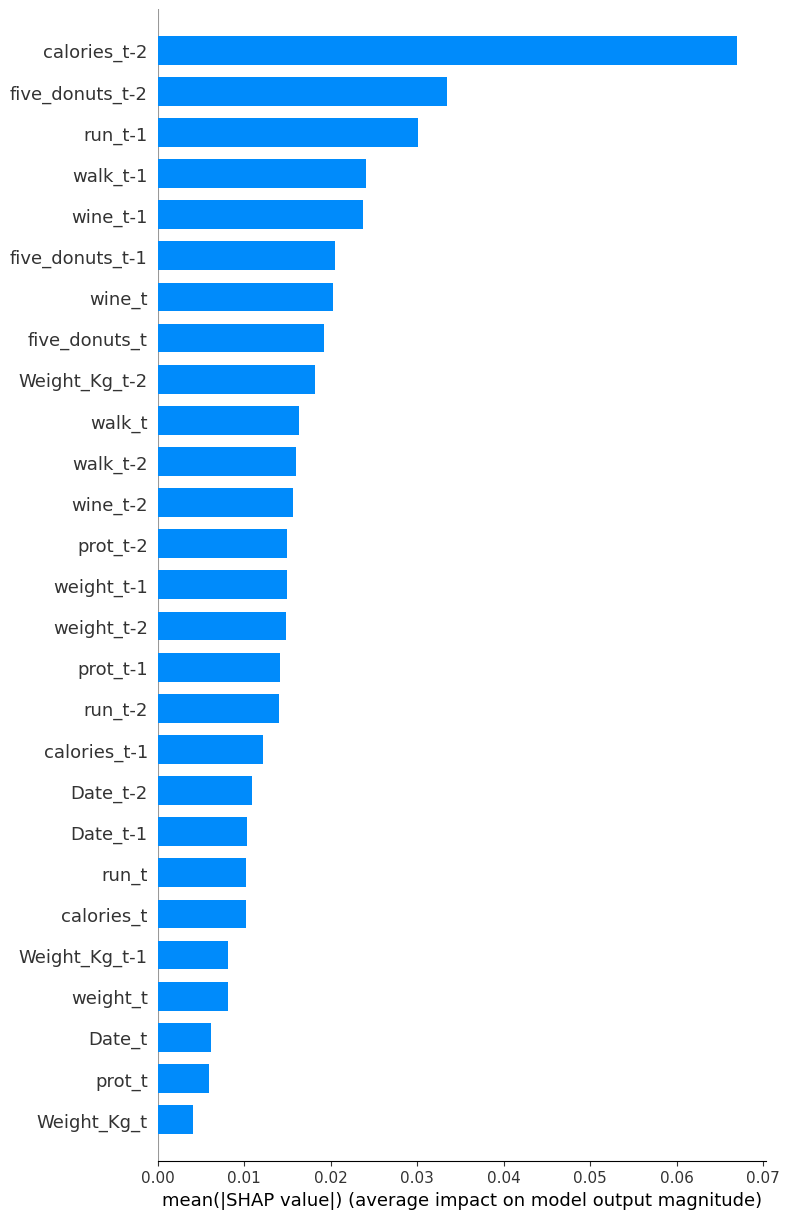

In [62]:
import shap
DE = shap.DeepExplainer(model, trainX) # X_train is 3d numpy.ndarray
shap_values = DE.shap_values(trainX, check_additivity=False) # X_validate is 3d numpy.ndarray

shap_val = np.array(shap_values)
shap_val = shap_val.squeeze(axis=0)
shap_val_aux = np.array(shap_values)
testX_aux = np.array(trainX)
#testX_2d = np.concatenate((trainX[:, 0, :]))#, trainX[:, 1, :], trainX[:, 2, :]), axis=1)
#shap_values_2d = np.concatenate((shap_val_aux[0][:, 0, :], shap_val_aux[0][:, 1, :], shap_val_aux[0][:, 2, :]), axis=1)


#reshaped_data = shap_val.reshape((shap_val.shape[0], -1))
shap_values_2d = shap_values[0][:, 0, :]
shap_t = shap_val[:, :, :]
shap_t = shap_t.reshape(shap_t.shape[0], -1)
test_graf = trainX[:, :, :]
test_graf = test_graf.reshape(test_graf.shape[0], -1)

col_names = list(all_Data.columns)

import pandas as pd

df_colunas = pd.DataFrame(col_names, columns=['col'])
lag = 3  # número de períodos atrasados
for i in range(lag):
    for col in col_names:
        if i == 0:
            df_colunas[f"{col}_t"] = df_colunas['col'].shift(i+1)
        else:
            df_colunas[f"{col}_t-{i}"] = df_colunas['col'].shift(i+1)

col_names = df_colunas.iloc[:, 1:].columns.tolist()
print(len(col_names))
print(col_names)
shap.initjs()
shap.summary_plot(
    shap_t, 
    test_graf,
    feature_names=col_names,
    max_display=51,
    plot_type='bar')

In [196]:

min_bin = 0
max_bin = 1
all_Data.head()

,Date,Weight_Kg,calories,cals_Kg,five_donuts,walk,run,wine,prot,weight
0,0,77.280800,1950,25.232658,1,1,0,0,0,0
1,1,76.430314,2600,34.017916,1,0,0,0,0,0
2,2,76.657110,2500,32.612761,1,1,0,0,0,0
3,3,76.657110,1850,24.133443,1,1,0,1,0,0
4,4,75.523130,2900,38.398832,1,1,0,0,0,0


In [203]:
transicoes = []
    
for feature_values in shap_values_2d.T:
    indices_transicao = np.where(np.diff(np.sign(feature_values)))[0]
        
    for indice in indices_transicao:
        if feature_values[indice] > 0 and feature_values[indice+1] < 0:
            transicoes.append((indice, feature_values[indice], feature_values[indice+1]))
            
with open('shapvaluesTransition_WEIGHT.csv', 'w', newline='') as arquivo_csv:
    # Criar o objeto de gravação do CSV
    escritor_csv = csv.writer(arquivo_csv)
    
    # Escrever o cabeçalho do CSV
    escritor_csv.writerow(['features', 'min', 'min', 'lim_inf', 'lim_sup'])
    
    for i, transicao in enumerate(transicoes):
            if not (i >= test_graf.shape[1]):
                feature_num = i + 1
                indice, valor_anterior, valor_posterior = transicao
                valor_feature_anterior = test_graf[indice, feature_num-1]
                valor_feature_posterior = test_graf[indice+1, feature_num-1]
                if i == 0 or i == 9 or i == 18:
                    valor_feature_anterior = round(valor_feature_anterior * (Date_max - Date_min) + Date_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (Date_max - Date_min) + Date_min, 2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{Date_min}] Max: [{Date_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {Date_min}, {Date_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 1 or i == 10 or i == 19:
                    valor_feature_anterior = round(valor_feature_anterior * (kg_max - kg_min) + kg_min,2)
                    valor_feature_posterior = round(valor_feature_posterior * (kg_max - kg_min) + kg_min,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{kg_min}] Max: [{kg_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {kg_min}, {kg_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 2 or i == 11 or i == 20:
                    valor_feature_anterior = round(valor_feature_anterior * (calories_max - calories_min) + calories_min,2)
                    valor_feature_posterior = round(valor_feature_posterior * (calories_max - calories_min) + calories_min,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{calories_min}] Max: [{calories_max}]")
                    escritor_csv.writerow([f"{col_names[i]}, {calories_min}, {calories_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 3 or i == 12 or i == 21:
                    valor_feature_anterior = round(valor_feature_anterior * (max_bin - min_bin) + min_bin,2)
                    valor_feature_posterior = round(valor_feature_posterior * (max_bin - min_bin) + min_bin,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{min_bin}] Max: [{max_bin}]")
                    escritor_csv.writerow([f"{col_names[i]}, {min_bin}, {max_bin}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 4 or i == 13 or i == 22:
                    valor_feature_anterior = round(valor_feature_anterior * (max_bin - min_bin) + min_bin,2)
                    valor_feature_posterior = round(valor_feature_posterior * (max_bin - min_bin) + min_bin,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{min_bin}] Max: [{max_bin}]")
                    escritor_csv.writerow([f"{col_names[i]}, {min_bin}, {max_bin}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 5 or i == 14 or i == 23:
                    valor_feature_anterior = round(valor_feature_anterior * (max_bin - min_bin) + min_bin,2)
                    valor_feature_posterior = round(valor_feature_posterior * (max_bin - min_bin) + min_bin,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{min_bin}] Max: [{max_bin}]")
                    escritor_csv.writerow([f"{col_names[i]}, {min_bin}, {max_bin}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 6 or i == 15 or i == 24:
                    valor_feature_anterior = round(valor_feature_anterior * (max_bin - min_bin) + min_bin,2)
                    valor_feature_posterior = round(valor_feature_posterior * (max_bin - min_bin) + min_bin,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{min_bin}] Max: [{max_bin}]")
                    escritor_csv.writerow([f"{col_names[i]}, {min_bin}, {max_bin}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 7 or i == 16 or i == 25:
                    valor_feature_anterior = round(valor_feature_anterior * (max_bin - min_bin) + min_bin,2)
                    valor_feature_posterior = round(valor_feature_posterior * (max_bin - min_bin) + min_bin,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{min_bin}] Max: [{max_bin}]")
                    escritor_csv.writerow([f"{col_names[i]}, {min_bin}, {max_bin}, {valor_feature_anterior}, {valor_feature_posterior}"])
                if i == 8 or i == 17 or i == 26:
                    valor_feature_anterior = round(valor_feature_anterior * (max_bin - min_bin) + min_bin,2)
                    valor_feature_posterior = round(valor_feature_posterior * (max_bin - min_bin) + min_bin,2)
                    print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}] -> Min: [{min_bin}] Max: [{max_bin}]")
                    escritor_csv.writerow([f"{col_names[i]}, {min_bin}, {max_bin}, {valor_feature_anterior}, {valor_feature_posterior}"])
            

Date_t: [9.0, 10.0] -> Min: [0] Max: [142]
Weight_Kg_t: [75.97, 76.37] -> Min: [74.5] Max: [78.47]
calories_t: [2000.0, 4150.0] -> Min: [1400] Max: [9150]
five_donuts_t: [1.0, 0.0] -> Min: [0] Max: [1]
walk_t: [0.0, 0.0] -> Min: [0] Max: [1]
run_t: [0.0, 1.0] -> Min: [0] Max: [1]
wine_t: [1.0, 0.0] -> Min: [0] Max: [1]
prot_t: [1.0, 1.0] -> Min: [0] Max: [1]
weight_t: [1.0, 1.0] -> Min: [0] Max: [1]
Date_t-1: [92.0, 93.0] -> Min: [0] Max: [142]
Weight_Kg_t-1: [75.52, 76.77] -> Min: [74.5] Max: [78.47]
calories_t-1: [2200.0, 2600.0] -> Min: [1400] Max: [9150]
five_donuts_t-1: [0.0, 0.0] -> Min: [0] Max: [1]
walk_t-1: [1.0, 0.0] -> Min: [0] Max: [1]
run_t-1: [0.0, 0.0] -> Min: [0] Max: [1]
wine_t-1: [0.0, 0.0] -> Min: [0] Max: [1]
prot_t-1: [0.0, 0.0] -> Min: [0] Max: [1]
weight_t-1: [1.0, 1.0] -> Min: [0] Max: [1]
Date_t-2: [134.0, 135.0] -> Min: [0] Max: [142]
Weight_Kg_t-2: [75.92, 76.31] -> Min: [74.5] Max: [78.47]
calories_t-2: [2800.0, 2300.0] -> Min: [1400] Max: [9150]
five_donuts

In [ ]:
sort = dataset[:-6,89]
sorted_val = sorted(sort)
for i in sorted_val:
    print(sorted_val)

In [582]:
maxa = all_Data['weight'].values[:-6].max()
calor = dataset[2:-4, 9]
cal_min = 1
cal_max = 1
indices = np.where((calor >= cal_min) & (calor <= cal_max))[0]
for i in indices:
    print (i)


34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
67
68
69
70
71
72
73
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
116
117
118
119
120
121
122
123
124
125
126
127
128
129


In [583]:
from scipy.stats import entropy

count_neg = 0
count_pos = 0

for idx in indices:
    shap = shap_val[idx][2][9]
    #print(shap)
    if shap < 0:
        #print('negative')
        count_neg += 1
    else:
        #print('positive')
        count_pos += 1
print("Calories: ")
print("Quantidade de valores no intervalo de {} a {} com SHAP negativo:".format(cal_min, cal_max), count_neg)
print("Quantidade de valores no intervalo de {} a {} com SHAP positivo:".format(cal_min, cal_max), count_pos)

total = count_neg + count_pos
prob_neg = count_neg/total
prob_pos = count_pos/total

calories_balance = [prob_neg, prob_pos]
print("\nEntropy:")
entrop = entropy(calories_balance, base=2)
print(entrop)
if entrop > 0.1:
    janela_inf = cal_max
    print("Encontrada janela superior: {}".format(cal_min))

Calories: 
Quantidade de valores no intervalo de 1 a 1 com SHAP negativo: 27
Quantidade de valores no intervalo de 1 a 1 com SHAP positivo: 35

Entropy:
0.9879565014919159
Encontrada janela superior: 1


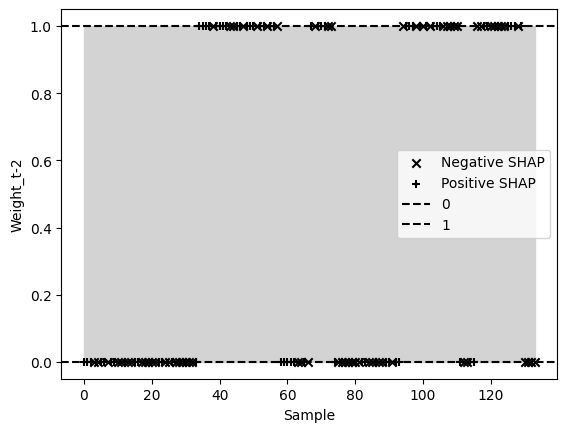

In [584]:
indice_neg = []
indice_pos = []
x = []

for idx in range(len(calor)):
    #shap = shap_t[idx][1]
    shap = shap_val[idx][2][9]
    if shap < 0:
        indice_neg.append(idx)
    else:
        indice_pos.append(idx)
    x.append(idx)

x = np.array(x)
        
#val_pos = all_Data.iloc[indice_pos, 2]
#val_neg = all_Data.iloc[indice_neg, 2]
val_pos = calor[indice_pos]
val_neg = calor[indice_neg]
linha1 = 0
linha2 = 1

plt.fill_between(x, linha1, linha2, color='lightgrey')

# Plot dos valores com SHAP negativo como pontos vermelhos
plt.scatter(indice_neg, val_neg, color='black', label='Negative SHAP', marker='x')

# Plot dos valores com SHAP positivo como pontos azuis
plt.scatter(indice_pos, val_pos, color='black', label='Positive SHAP', marker='+')

plt.axhline(y=linha1, color='black', linestyle='--', label='0')
plt.axhline(y=linha2, color='black', linestyle='--', label='1')

plt.xlabel('Sample')
plt.ylabel('Weight_t-2')
plt.legend()
plt.savefig('entropia/weight_t-2_graph_entrop.pdf', format='pdf')
plt.show()

In [24]:
all_Data.head()

,Date,Peso_Kg,calories,cals_Kg,five_donuts,walk,run,wine,prot,weight
0,0,77.280800,1950,25.232658,1,1,0,0,0,0
1,1,76.430314,2600,34.017916,1,0,0,0,0,0
2,2,76.657110,2500,32.612761,1,1,0,0,0,0
3,3,76.657110,1850,24.133443,1,1,0,1,0,0
4,4,75.523130,2900,38.398832,1,1,0,0,0,0


In [108]:
# Preparação dos dados
X = trainX[:, :, :]
X = X.reshape(X.shape[0], -1)
indices_remover = [0, 3, 10, 13, 20, 23]  # Índices das colunas a serem removidas
X = np.delete(X, indices_remover, axis=1)
shap_values = shap_val[:, :, :]
shap_values = shap_values.reshape(shap_t.shape[0], -1)
y = []
w = []
interator = shap_values.shape[0]

#for idx in range(interator):
 #   shap = shap_values[idx]
  #  shap_f = 0
   # for i in range(len(shap)):
    #    shap_f += shap[i]
    #if shap_f > 0:
     #   c = '+'
      #  y.append(c)
    #else:
     #   c = '-'
      #  y.append(c)
        
for idx in range(interator):
    shap = shap_values[idx]
    shap_f = shap[29]
    if shap_f > 0:
        c = '+'
        w.append(c)
    else:
        c = '-'
        w.append(c)
        
print(len(w))

#indice_pos = [idx for idx, shap in enumerate(shap_values) if shap > 0]
#indice_neg = [idx for idx, shap in enumerate(shap_values) if shap < 0]

# Define as classes SHAP (+ ou -)
#y = ['+' if idx in indice_pos else '-' for idx in range(X.shape[0])]

# Criação da árvore de decisão
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion = "entropy")
tree.fit(X, w)


134


DecisionTreeClassifier(criterion='entropy')

In [109]:
from sklearn.tree import export_graphviz

col_names = list(all_Data.columns)

import pandas as pd

df_colunas = pd.DataFrame(col_names, columns=['col'])
lag = 3  # número de períodos atrasados
for i in range(lag):
    for col in col_names:
        if i == 0:
            df_colunas[f"{col}_t"] = df_colunas['col'].shift(i+1)
        else:
            df_colunas[f"{col}_t-{i}"] = df_colunas['col'].shift(i+1)

col_names = df_colunas.iloc[:, 1:].columns.tolist()
indice_t = col_names.index("Peso_Kg_t")
indice_t_1 = col_names.index("Peso_Kg_t-1")
indice_t_2 = col_names.index("Peso_Kg_t-2")
col_names[indice_t] = "Weight_Kg"
col_names[indice_t_1] = "Weight_Kg_t-1"
col_names[indice_t_2] = "Weight_Kg_t-2"
col_names = [col for i, col in enumerate(col_names) if i not in indices_remover]

# Creates dot file named tree.dot
export_graphviz(
            tree,
            out_file =  "myTreeName.dot",
            feature_names = col_names,
            class_names = ['-','+'],
            filled = True,
            rounded = True)

export_graphviz(
            tree,
            out_file =  "Weight_t-2.dot",
            feature_names = col_names,
            class_names = ['-','+'],
            filled = True,
            rounded = True)

In [ ]:
shap.summary_plot(shap_t, test_graf, col_names, max_display=51)
#shap.summary_plot(shap_values_2d, feature_names = col_names, features = testX_2d, max_display=51)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


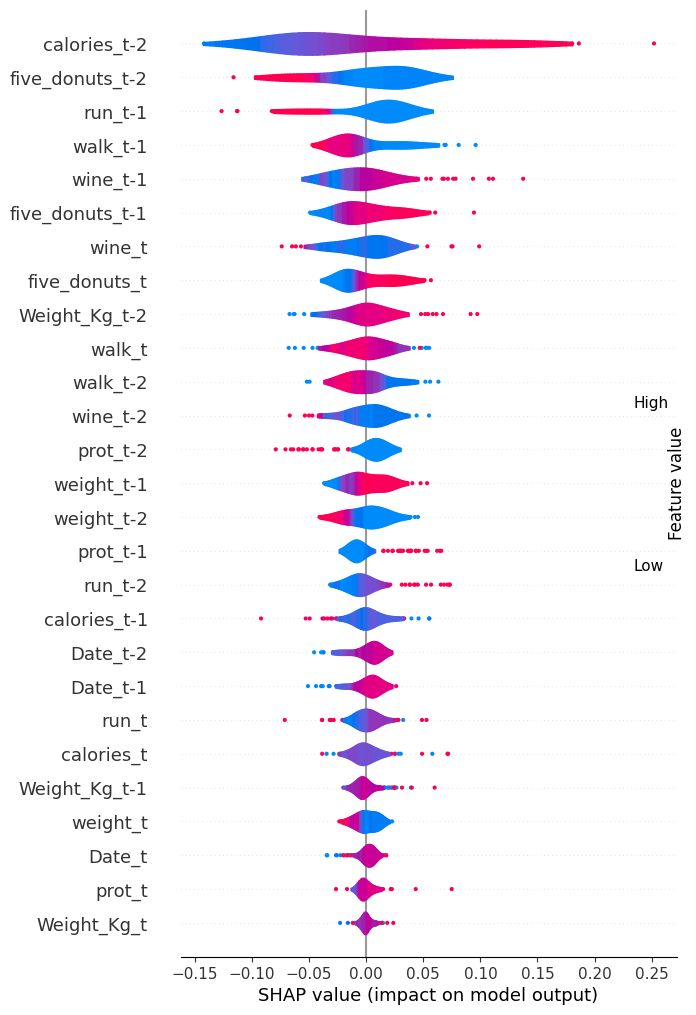

In [121]:
#shap.plots.violin(shap_t, feature_names = col_names, features=test_graf, max_display=51, show=False)
#plt.legend(loc='center right')
#plt.savefig('violin.pdf', format='pdf', dpi=600, bbox_inches='tight')
#plt.show()


# Gerar os gráficos de violin plot
shap.plots.violin(shap_t, features=test_graf, feature_names=col_names, max_display=51, show=False)

# Obter os eixos da figura
axes = plt.gcf().axes

# Remover a legenda anterior
#axes[-1].remove()

# Obter a posição atual do último eixo
pos = axes[-1].get_position()

# Definir a nova posição do último eixo deslocando-o para a esquerda
new_pos = [pos.x0 - 0.1, pos.y0, pos.width, pos.height]
axes[-1].set_position(new_pos)



# Salvar o gráfico em um arquivo
plt.savefig('violin.pdf', format='pdf', dpi=600, bbox_inches='tight')

# Exibir o gráfico
plt.show()

In [93]:
help(shap.plots.violin)

Help on function violin in module shap.plots._violin:

violin(shap_values, features=None, feature_names=None, max_display=None, plot_type='violin', color=None, axis_color='#333333', title=None, alpha=1, show=True, sort=True, color_bar=True, plot_size='auto', layered_violin_max_num_bins=20, class_names=None, class_inds=None, color_bar_label='Feature value', cmap=<matplotlib.colors.LinearSegmentedColormap object at 0x000002B5372DB370>, auto_size_plot=None, use_log_scale=False)
    Create a SHAP beeswarm plot, colored by feature values when they are provided.
    
    Parameters
    ----------
    shap_values : numpy.array
        For single output explanations this is a matrix of SHAP values (# samples x # features).
        For multi-output explanations this is a list of such matrices of SHAP values.
    
    features : numpy.array or pandas.DataFrame or list
        Matrix of feature values (# samples x # features) or a feature_names list as shorthand
    
    feature_names : list
    

<Figure size 640x480 with 0 Axes>

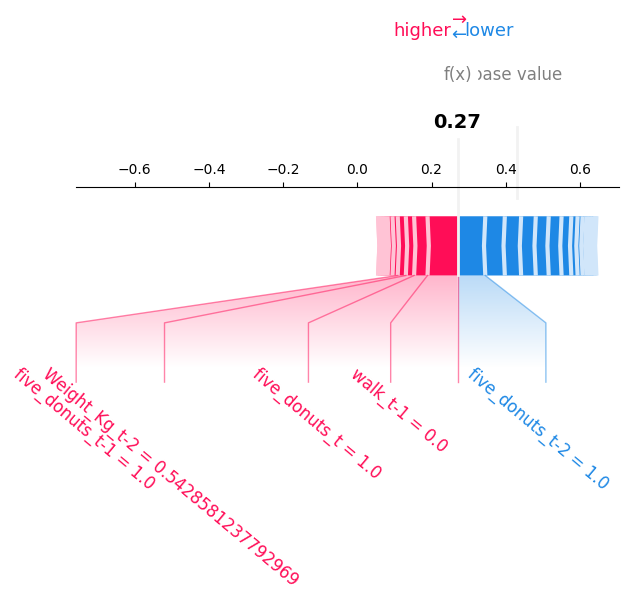

In [132]:

plt.clf()
shap.plots.force(DE.expected_value, shap_t[0], test_graf[0],figsize=(7, 5), feature_names=col_names, matplotlib = True, show=False, text_rotation=)
plt.savefig('force.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

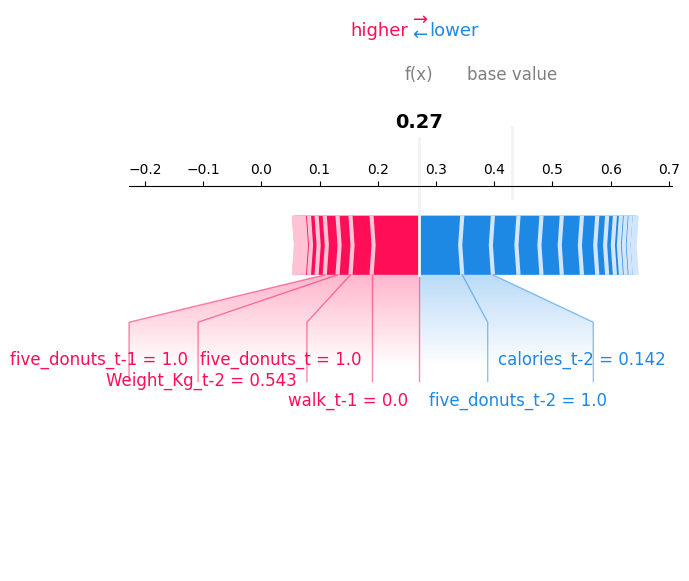

In [181]:
import re
# Inicializar o ambiente JS necessário para o gráfico force plot
shap.initjs()

# Gerar o gráfico force plot
force_plot = shap.force_plot(DE.expected_value, shap_t[0], test_graf[0], feature_names=col_names, matplotlib=True, show=False)

# Obter a figura e os eixos do gráfico
fig, ax = plt.gcf(), plt.gca()

# Iterar sobre os textos do gráfico e ajustar as posições
for i, text in enumerate(ax.texts):
    x = text.get_position()[0]  # Obter a posição x atual do texto
    y = text.get_position()[1]  # Obter a posição y atual do texto
    
    # Ajustar a posição de cada texto individualmente
    if i == 0 or i == 2 or i == 4:
        text.set_position((x, y - 0.07))
    if i == 4:
        text.set_position((x, y - 0.035))
        
# Iterar sobre os textos do gráfico e ajustar a formatação dos valores
i=-1
for text in ax.texts:
    i = i+1
    # Obter o valor original do texto
    original_text = text.get_text()
    if i == 1 or i == 4:
        try:
            # Extrair o número da string após o sinal de igual
            number = re.findall(r"= ([+-]?\d*\.\d+|\d+)", original_text)[0]
            # Converter o número para float e formatar com duas casas decimais
            formatted_text = "{:.3f}".format(float(number))
            # Substituir o valor original pelo novo texto formatado
            text.set_text(original_text.replace(number, formatted_text))
        except IndexError:
            # Caso ocorra um erro ao extrair o número, manter o texto original
            pass
fig.set_size_inches(7, 5)  # Ajuste os valores conforme necessário


# Salvar o gráfico em um arquivo PDF
plt.savefig('force.pdf', format='pdf', dpi=600, bbox_inches='tight')

# Exibir o gráfico
plt.show()

In [ ]:
transicoes = []
    
for feature_values in shap_values_2d.T:
    indices_transicao = np.where(np.diff(np.sign(feature_values)))[0]
        
    for indice in indices_transicao:
        if feature_values[indice] > 0 and feature_values[indice+1] < 0:
            transicoes.append((indice, feature_values[indice], feature_values[indice+1]))
for i, transicao in enumerate(transicoes):
        if not (i >= datasetFinal.shape[1]):
            feature_num = i + 1
            indice, valor_anterior, valor_posterior = transicao
            valor_feature_anterior = datasetFinal.iloc[indice, i]
            valor_feature_posterior = datasetFinal.iloc[indice+1, i]

            print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}]")

In [ ]:
transicoes = []
    
for feature_values in shap_values_2d.T:
    indices_transicao = np.where(np.diff(np.sign(feature_values)))[0]
        
    for indice in indices_transicao:
        if feature_values[indice] > 0 and feature_values[indice+1] < 0:
            transicoes.append((indice, feature_values[indice], feature_values[indice+1]))
            
with open('shapvaluesTransition_WeightKg.csv', 'w', newline='') as arquivo_csv:
    # Criar o objeto de gravação do CSV
    escritor_csv = csv.writer(arquivo_csv)
    
    # Escrever o cabeçalho do CSV
    escritor_csv.writerow(['features', 'min', 'min', 'lim_inf', 'lim_sup'])
    
    for i, transicao in enumerate(transicoes):
            if not (i >= datasetFinal.shape[1]):
                feature_num = i + 1
                indice, valor_anterior, valor_posterior = transicao
                valor_feature_anterior = testX_2d[indice, feature_num-1]
                valor_feature_posterior = testX_2d[indice+1, feature_num-1]
                another = 0
                if i == 0 or i == 10 or i == 20:
                    valor_feature_anterior = round(valor_feature_anterior * (Date_max - Date_min) + Date_min)
                    valor_feature_posterior = round(valor_feature_posterior * (Date_max - Date_min) + Date_min)
                    escritor_csv.writerow([f"{col_names[i]}, {Date_min}, {Date_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                    another = 1
                if i == 1 or i == 11 or i == 21:
                    valor_feature_anterior = round(valor_feature_anterior * (kg_max - kg_min) + kg_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (kg_max - kg_min) + kg_min, 2)
                    escritor_csv.writerow([f"{col_names[i]}, {kg_min}, {kg_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                    another = 1
                if i == 2 or i == 12 or i == 22:
                    valor_feature_anterior = round(valor_feature_anterior * (calories_max - calories_min) + calories_min)
                    valor_feature_posterior = round(valor_feature_posterior * (calories_max - calories_min) + calories_min)
                    escritor_csv.writerow([f"{col_names[i]}, {calories_min}, {calories_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                    another = 1
                if i == 3 or i == 13 or i == 23:
                    valor_feature_anterior = round(valor_feature_anterior * (cals_Kg_max - cals_Kg_min) + cals_Kg_min, 2)
                    valor_feature_posterior = round(valor_feature_posterior * (cals_Kg_max - cals_Kg_min) + cals_Kg_min, 2)
                    escritor_csv.writerow([f"{col_names[i]}, {cals_Kg_min}, {cals_Kg_max}, {valor_feature_anterior}, {valor_feature_posterior}"])
                    another = 1
                if another == 0:
                    escritor_csv.writerow([f"{col_names[i]}, 0, 1, {valor_feature_anterior}, {valor_feature_posterior}"])
    
                print(f"{col_names[i]}: [{valor_feature_anterior}, {valor_feature_posterior}]")

In [ ]:
shap.plots._waterfall.waterfall_legacy(DE.expected_value[0], shap_t[6], test_graf[6], feature_names=col_names, max_display=51)

In [ ]:
model_gru = Sequential()
model_gru.add(GRU(75, return_sequences=True,input_shape=(look_back, trainX.shape[2])))
model_gru.add(GRU(units=30, return_sequences=True))
model_gru.add(GRU(units=30))
model_gru.add(Dense(units=1))
model_gru.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
#fit the GRU network
for i in range(7):
    model_gru.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

In [ ]:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
trainPredict_GRU = model_gru.predict(trainX)
testPredict_GRU = model_gru.predict(testX)

In [ ]:
testScore_LSTM = np.sqrt(mean_squared_error(testY, testPredict))
print('Test Score LSTM: %.2f RMSE' % (testScore_LSTM))
testScore_GRU = np.sqrt(mean_squared_error(testY, testPredict_GRU))
print('Test Score GRU: %.2f RMSE' % (testScore_GRU))

In [ ]:
trainScore_LSTM = np.sqrt(mean_squared_error(trainY, trainPredict))
print('Train Score LSTM: %.2f RMSE' % (trainScore_LSTM))
trainScore_GRU = np.sqrt(mean_squared_error(trainY, trainPredict_GRU))
print('Train Score GRU: %.2f RMSE' % (trainScore_GRU))

In [ ]:
trainPredict_Conv_1_LSTM = trainPredict * (kg_max - kg_min) + kg_min
#trainPredict_Conv_2_LSTM = trainPredict[:, 1] * (bmi_max - bmi_min) + bmi_min
#trainPredict_Conv_3_LSTM = trainPredict[:, 2] * (bmi_max - bmi_min) + bmi_min
testPredict_Conv_1_LSTM = testPredict *(kg_max - kg_min) + kg_min
#testPredict_Conv_2_LSTM = testPredict[:,1] *(bmi_max - bmi_min) + bmi_min
#testPredict_Conv_3_LSTM = testPredict[:,2] *(bmi_max - bmi_min) + bmi_min
trainPredict_Conv_1_GRU = trainPredict_GRU * (kg_max - kg_min) + kg_min
#trainPredict_Conv_2_GRU = trainPredict_GRU[:, 1] * (bmi_max - bmi_min) + bmi_min
#trainPredict_Conv_3_GRU = trainPredict_GRU[:, 2] * (bmi_max - bmi_min) + bmi_min
testPredict_Conv_1_GRU = testPredict_GRU * (kg_max - kg_min) + kg_min
#testPredict_Conv_2_GRU = testPredict_GRU[:, 1] * (bmi_max - bmi_min) + bmi_min
#testPredict_Conv_3_GRU = testPredict_GRU[:, 2] * (bmi_max - bmi_min) + bmi_min
testY_Conv = testY * (kg_max - kg_min) + kg_min

In [ ]:
xall = list(range(1, 141))
xtrain = list(range(5, 92))
xtest = list(range(96, 137))

In [ ]:
Data_real = all_Data['Peso_Kg']

In [ ]:
plt.plot(xall, Data_real, label='Dados reais')
plt.plot(xtrain, trainPredict_Conv_1_LSTM, label='Train LSTM')
plt.plot(xtrain, trainPredict_Conv_1_GRU, label='Train GRU')
plt.plot(xtest, testPredict_Conv_1_LSTM, label='Test LSTM')
plt.plot(xtest, testPredict_Conv_1_GRU, label='Test GRU')
plt.legend()

In [ ]:
plt.plot(xtest, testY_Conv, label='Dados reais')
#plt.plot(xtrain, trainPredict_Conv_1_LSTM, label='Train LSTM')
#plt.plot(xtrain, trainPredict_Conv_1_GRU, label='Train GRU')
plt.plot(xtest, testPredict_Conv_1_LSTM, label='Test LSTM')
plt.plot(xtest, testPredict_Conv_1_GRU, label='Test GRU')
plt.legend()

In [ ]:
print(testX.shape)
print(shap_values_2d.shape)

In [ ]:
all_Data.shape

In [ ]:
# Definir o número de colunas e linhas do novo dataset com lookback de 3
num_colunas_originais = all_Data.shape[1]
num_colunas_novo = num_colunas_originais * 3
num_linhas_novo = all_Data.shape[0] - 2

# Criar o novo dataset com as dimensões desejadas e os nomes de colunas
dataset_novo = pd.DataFrame(columns=all_Data.columns)

# Preencher o novo dataset com base nos dados do dataset original
for i in range(num_linhas_novo):
    dados_linha_novo = []
    
    for j in range(num_colunas_novo):
        coluna_origem = j // 3
        lookback = j % 3
        
        if lookback == 0:
            dados_linha_novo.append(all_Data.iloc[i, coluna_origem])
        else:
            coluna_t = coluna_origem * 3 + lookback - 1
            indice_linha = coluna_t
            if indice_linha < all_Data.shape[1]:
                dados_linha_novo.append(all_Data.iloc[indice_linha, coluna_t])
            else:
                dados_linha_novo.append(np.nan)
    
    dataset_novo.loc[i] = pd.Series(dados_linha_novo, index=dataset_novo.columns)

# Exibir o novo dataset
print(dataset_novo)

In [ ]:
test_graf.shape

In [ ]:
trainX.shape

In [ ]:
shap_t.shape

In [ ]:
all_Data.shape

In [ ]:
trainX[:, 0, :]

In [ ]:
len(trainX[:, 0, :])

In [ ]:
shap_val.shape

In [ ]:
trainX.shape

In [ ]:
dataset[-7, 0]

In [ ]:
trainX[-1, 0, 0]

In [200]:
test_graf.shape

(134, 27)

In [364]:
calor[2]

2900.0

In [591]:
len(col_names)

30

In [599]:
shap_values.shape

(134, 30)

In [630]:
X

array([[0.        , 0.70000076, 0.07096775, ..., 0.        , 0.        ,
        0.        ],
       [0.00704225, 0.48571396, 0.1548387 , ..., 1.        , 0.        ,
        0.        ],
       [0.01408451, 0.5428581 , 0.14193548, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.9436619 , 0.34285736, 0.11612903, ..., 0.        , 0.        ,
        0.        ],
       [0.9507042 , 0.2142868 , 0.12903227, ..., 1.        , 0.        ,
        0.        ],
       [0.95774645, 0.2142868 , 0.09032257, ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [187]:
shap_val.shape

(134, 3, 9)

In [202]:
print(col_names)

['Date_t', 'Weight_Kg_t', 'calories_t', 'five_donuts_t', 'walk_t', 'run_t', 'wine_t', 'prot_t', 'weight_t', 'Date_t-1', 'Weight_Kg_t-1', 'calories_t-1', 'five_donuts_t-1', 'walk_t-1', 'run_t-1', 'wine_t-1', 'prot_t-1', 'weight_t-1', 'Date_t-2', 'Weight_Kg_t-2', 'calories_t-2', 'five_donuts_t-2', 'walk_t-2', 'run_t-2', 'wine_t-2', 'prot_t-2', 'weight_t-2']
